# Notebook 03 — Pré-Processamento dos Dados

**Projeto:** Mineração de Dados em Saúde · PNS 2019
**Estudo:** Artrite e Reumatismo em Idosos Brasileiros
**Pesquisador:** Pedro Dias Soares
**Orientador:** Prof. Dr. Luis Enrique Zárate — PUC Minas
**Periódico-alvo:** Journal of Health Informatics (JHI/SBIS)

---

## Por que esta etapa existe?

Os algoritmos de Machine Learning não toleram dados em formato bruto da PNS:
texto onde deveria haver número, células vazias, escalas diferentes, doenças
codificadas como `'1'`/`'2'`, etc. Este notebook **transforma o dado bruto em
um dataset pronto para o classificador**, mantendo rastreabilidade de cada
decisão metodológica.

## Fluxo geral

| # | Etapa | O que faz |
|---|-------|-----------|
| 1 | Configuração | Imports, caminhos e constantes |
| 2 | Definição de variáveis | Listas tipadas (contínuas, discretas, nominais, ordinais) |
| 3 | Carregamento | Lê SQLite, aplica filtros V0015 + M001 |
| 4 | Conversão de tipos | Strings → números |
| 5 | ⭐ Skip patterns | Preenche NaN estrutural do questionário |
| 6 | Auditoria de missing | Exclui variáveis com >75% ausente |
| 7 | Outliers | IQR × 3,0 por classe → NaN |
| 8 | Imputação | Média/moda por classe (apenas missing real) |
| 9 | Fusão de atributos | IMC, escores inflamatório/saudável, razão |
| 10 | Categorização | Faixas etárias, IMC-OMS, atividade física |
| 11 | Encoding | Label Encoding (ordinais) + OHE (nominais) |
| 12 | Dataset final | Monta X, y e diagnóstico de balanceamento |
| 13 | Exportação | CSV + JSON de rastreabilidade |

> Convenção de cor: <span style="color:#C0392B">**vermelho = Com Artrite**</span>, <span style="color:#27AE60">**verde = Saudável**</span>.

## 1 · Configuração do ambiente

Carrega as bibliotecas, define caminhos relativos a `notebooks/` e fixa
os hiperparâmetros do pipeline:

- **`RANDOM_STATE = 42`** — semente para qualquer operação aleatória (reprodutibilidade).
- **`ALPHA = 0.05`** — nível de significância usado em testes inferenciais.
- **`LIMITE_MISSING = 0.75`** — variáveis com mais de 75% de células vazias serão **descartadas** (Etapa 6).
- **`LIMITE_IQR_MULT = 3.0`** — multiplicador do IQR para detecção de outliers (equivale a ~3,3 desvios-padrão numa distribuição normal). Conservador, derruba só valores muito extremos.

In [1]:
import sqlite3, os, math, warnings, json   # utilitários da std-lib
import pandas as pd                         # manipulação tabular
import numpy as np                          # operações vetoriais
import matplotlib.pyplot as plt             # plots base
import seaborn as sns                       # heatmaps e boxplots estilizados
from scipy import stats                     # testes estatísticos (não usado aqui, herdado de v3)

warnings.filterwarnings('ignore')           # silencia avisos de depreciação do pandas/seaborn

# ── Caminhos (relativos a notebooks/) ─────────────────────────────────
PASTA_DB       = '../data/database/'                       # bancos SQLite por subgrupo
DIR_RESULTADOS = '../data/results/preprocessing/'          # saídas deste notebook
DIR_FIGURAS    = DIR_RESULTADOS + 'figuras/'               # PNGs (heatmap, boxplots…)
DIR_TABELAS    = DIR_RESULTADOS + 'tabelas/'               # CSVs de rastreabilidade
for pasta in [DIR_RESULTADOS, DIR_FIGURAS, DIR_TABELAS]:   # garante existência das três
    os.makedirs(pasta, exist_ok=True)                      # não falha se já existir

# ── Hiperparâmetros do pipeline ───────────────────────────────────────
RANDOM_STATE    = 42      # semente fixa para reprodutibilidade
ALPHA           = 0.05    # nível de significância (5%)
LIMITE_MISSING  = 0.75    # corte de exclusão por % missing real (75%)
LIMITE_IQR_MULT = 3.0     # multiplicador IQR para detectar outliers

# ── Paleta cromática consistente entre notebooks ──────────────────────
COR_ARTRITE  = '#C0392B'  # vermelho (Com Artrite)
COR_SAUDAVEL = '#27AE60'  # verde    (Saudável)

# ── Estilo dos plots ──────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)           # grid leve, fontes maiores
plt.rcParams.update({                                       # ajustes globais do matplotlib
    'figure.dpi': 120,                                      # nitidez na visualização
    'axes.spines.top': False,                               # remove borda superior
    'axes.spines.right': False,                             # remove borda direita
})

# ── Funções auxiliares de I/O ─────────────────────────────────────────
def salvar_fig(nome):                                       # salva figura ativa do matplotlib
    caminho = DIR_FIGURAS + nome                            # caminho completo
    plt.savefig(caminho, dpi=150, bbox_inches='tight')      # alta resolução e crop justo
    print(f'  ✅ Figura → {caminho}')                       # log para auditoria

def salvar_tab(df, nome):                                   # salva DataFrame em CSV (utf-8-sig p/ Excel)
    caminho = DIR_TABELAS + nome                            # caminho completo
    df.to_csv(caminho, encoding='utf-8-sig')                # BOM para acentos no Excel BR
    print(f'  ✅ Tabela → {caminho}')                       # log para auditoria

def sig(p):                                                 # classifica p-valor em estrelas
    if p < 0.001: return '***'                              # altamente significativo
    if p < 0.01:  return '**'                               # muito significativo
    if p < 0.05:  return '*'                                # significativo
    return 'ns'                                             # não significativo

print('✅ Ambiente configurado.')                           # confirmação visual
print(f'   LIMITE_MISSING  : {LIMITE_MISSING*100:.0f}%')    # ecoa o corte de missing
print(f'   LIMITE_IQR_MULT : {LIMITE_IQR_MULT}×IQR')        # ecoa o corte de outlier

✅ Ambiente configurado.
   LIMITE_MISSING  : 75%
   LIMITE_IQR_MULT : 3.0×IQR


## 2 · Definição das variáveis do estudo

Cada lista agrupa as variáveis pelo **tipo estatístico**, o que decide depois:

- **Contínuas** → imputação por média, escalonamento, podem ter outliers reais.
- **Discretas** → também numéricas, mas valores limitados (0–7 dias/semana, etc.).
- **Nominais** → categorias sem ordem → vão para **One-Hot Encoding**.
- **Ordinais** → categorias com ordem natural (ex.: "muito boa < boa < ruim") → **Label Encoding** preservando a ordem.

### Nota sobre Peso/Altura

A PNS oferece dois pares:

| Código | Origem | Precisão |
|--------|--------|----------|
| `P00103/P00403` | Auto-referido (a pessoa diz) | Menor |
| `P00104/P00404` | Aferido (entrevistador mede) | **Maior** |

Usamos os **aferidos**, pois pessoas obesas tendem a subestimar peso e superestimar altura.

### Variáveis com skip pattern (resolvido na Etapa 5)

`P035`, `P02801`, `P029`, `P03201`, `J012`, `G060`, `G062` — só são perguntadas se a pergunta "pai" tiver certa resposta. Quando a pessoa "pula", o campo fica NaN sem ser dado faltante de verdade.

In [2]:
# Variáveis contínuas — valores reais em escala numérica
VARS_CONTINUAS = [
    'P00104',   # Peso aferido (kg)
    'P00404',   # Altura aferida (cm)
    'VDF004',   # Faixa de rendimento domiciliar per capita (1–7)
]

# Variáveis discretas — números inteiros (contagens, dias/semana, anos)
VARS_DISCRETAS = [
    'C008',     # Idade (anos)
    'P035',     # Exercício físico (dias/sem.)   — CONDICIONAL: só se P034=1
    'P04501',   # Televisão (horas/dia)
    'P00901',   # Verduras/legumes (dias/sem.)
    'P015',     # Peixe (dias/sem.)
    'P018',     # Frutas (dias/sem.)
    'P01101',   # Carne vermelha (dias/sem.)
    'P02501',   # Doces/ultraprocessados (dias/sem.)
    'P02002',   # Refrigerante (dias/sem.)
    'P02001',   # Suco em pó/caixinha (dias/sem.)
    'P023',     # Leite (dias/sem.)
    'P01601',   # Suco de fruta natural (dias/sem.)
    'P02602',   # Lanche rápido substituindo almoço (dias/sem.)
    'P006',     # Feijão (dias/sem.)
    'P013',     # Frango/galinha (dias/sem.)
    'J012',     # Consultas médicas/12m          — CONDICIONAL: só se J01101=1
    'P02801',   # Dias/sem. com álcool           — CONDICIONAL: só se P027=3
    'P029',     # Doses de álcool por ocasião    — CONDICIONAL: só se P027≠1
    'P03202',   # Máx. doses em episódio de binge   — CONDICIONAL: só se P03201=1
]

# Variáveis nominais — categorias sem ordem (vão para One-Hot Encoding)
VARS_NOMINAIS = [
    'C006',     # Sexo (1=Masc, 2=Fem)
    'P034',     # Praticou exercício? — PAI de P035
    'I00102',   # Tem plano de saúde médico? (I00101 era odontológico)
    'J01101',   # Quando consultou médico? — PAI de J012
    'J01002',   # Local usual de atendimento
    'G059',     # Usa aparelho de auxílio à locomoção? — PAI de G060/G062
    'G060',     # Usa cadeira de rodas?            — CONDICIONAL: só se G059=1
    'G062',     # Usa bengala/muleta/andador?      — CONDICIONAL: só se G059=1
    'Q092',     # Diagnóstico de depressão
    'Q11006',   # Outra doença mental
    'Q00201',   # Hipertensão
    'Q03001',   # Diabetes
    'Q060',     # Colesterol alto
    'Q06306',   # Doença cardíaca
    'Q068',     # AVC
    'Q084',     # Problema crônico de coluna
    'Q074',     # Asma
    'Q120',     # Câncer
    'Q124',     # Insuficiência renal crônica
    'Q11604',   # DPOC
    'P00603',   # Feijão no dia anterior
    'P00620',   # Embutidos no dia anterior
    'P02601',   # Percepção do consumo de sal
    'P027',     # Frequência de álcool — PAI de P028/P029/P03201
    'P03201',   # Binge drinking 30d              — CONDICIONAL: só se P027≠1
    'P02401',   # Tipo de leite (desnatado/integral/ambos)
    'P02101',   # Tipo de suco em pó (diet/light/zero ou normal)
    'P02102',   # Tipo de refrigerante (diet/light/zero ou normal)
    'P00612',   # Leite — consumo no dia anterior
    'P00614',   # Refrigerante — consumo no dia anterior
    'P00615',   # Suco de caixinha/refresco em pó — dia anterior
    'P00616',   # Bebida achocolatada/iogurte c/ sabor — dia anterior
    'Q04708',   # Foi pedido exame de hemoglobina glicada — CONDICIONAL (diabéticos)
    'Q047081',  # Realizou exame de hemoglobina glicada — CONDICIONAL
    'Q04711',   # Foi pedido exame de colesterol/triglicerídeos — CONDICIONAL
    'Q047111',  # Realizou exame de colesterol/triglicerídeos — CONDICIONAL
]

# Variáveis ordinais — categorias com ordem natural (Label Encoding)
VARS_ORDINAIS = [
    'VDD004A',  # Escolaridade (1=Sem instrução … 5=Superior)
    'N001',     # Autoavaliação de saúde (1=Muito boa … 5=Muito ruim)
    'N010',     # Problemas de sono
    'N011',     # Cansaço/falta de energia
    'G070',     # Dificuldade de caminhar/subir degraus
    'Q115',     # Limitação por doença mental
    'Q109',     # Limitação pela depressão
    'G079',     # Dificuldade p/ levantar garrafa 2L (com auxílio)
    'G080',     # Dificuldade p/ pegar objetos pequenos
    'G081',     # Dificuldade p/ levantar garrafa 2L (sem auxílio)
    'Q05901',   # Tempo desde o último exame de colesterol/triglicerídeos
]

# União de tudo + variável-alvo Q079 (artrite Sim/Não)
TODAS_VARS = VARS_CONTINUAS + VARS_DISCRETAS + VARS_NOMINAIS + VARS_ORDINAIS + ['Q079']

# Diagnóstico das listas
print(f'✅ Variáveis definidas:')
print(f'   Contínuas     : {len(VARS_CONTINUAS)}')
print(f'   Discretas     : {len(VARS_DISCRETAS)}  (inclui condicionais c/ skip pattern)')
print(f'   Nominais      : {len(VARS_NOMINAIS)}  (inclui condicionais c/ skip pattern)')
print(f'   Ordinais      : {len(VARS_ORDINAIS)}')
print(f'   TOTAL features: {len(VARS_CONTINUAS)+len(VARS_DISCRETAS)+len(VARS_NOMINAIS)+len(VARS_ORDINAIS)}')

✅ Variáveis definidas:
   Contínuas     : 3
   Discretas     : 19  (inclui condicionais c/ skip pattern)
   Nominais      : 36  (inclui condicionais c/ skip pattern)
   Ordinais      : 11
   TOTAL features: 69


## 3 · Carregamento das bases SQLite

Carrega duas bases — `idosos_artrite_puro.db` (494 idosos, target=1) e
`idosos_saudaveis.db` (4 332 idosos, target=0) — produzidas pelo **Notebook 01**.

### Por que dois filtros de integridade?

A PNS marca cada questionário com dois flags:

| Flag | Significado | Quando aplicar |
|------|-------------|----------------|
| `V0015 = 1` | Entrevista do **domicílio** realizada | Sempre |
| `M001 = 1` | Questionário **individual** do adulto selecionado realizado | Só se ≥10% dos registros tiverem esse campo preenchido |

Por que o cutoff de 10% em `M001`? Em bases derivadas (já filtradas), boa parte dos moradores não-selecionados aparece com `M001=NaN`. Aplicar o filtro nesse caso eliminaria *todos* os registros. O guard de 10% evita o auto-shoot na perna.

Os filtros suportam o valor em 4 formatos (`1`, `'1'`, `'01'`, `'realizada'`) porque a PNS armazena V0015 como string de largura fixa.

In [3]:
print('Executando a partir de:', os.getcwd())  # confirma diretório de trabalho

# Lista de colunas a buscar no SQL (sem duplicar V0015/M001 que aparecem em TODAS_VARS por engano)
colunas_sql = list(dict.fromkeys(['V0015', 'M001'] + TODAS_VARS))
SQL_NB03 = f"SELECT {', '.join(colunas_sql)} FROM pns_idosos"  # query base

# Mapeia arquivo SQLite → rótulo do grupo (label do problema de classificação)
ARQUIVOS = {
    'idosos_artrite_puro.db': 'Com Artrite',   # target = 1 (artrite pura, sem comorbidades)
    'idosos_saudaveis.db'   : 'Saudável',      # target = 0 (sem nenhuma das 14 doenças)
}

dfs, log_carga = [], []                         # acumuladores: lista de DFs e log de carga

for arquivo, classe in ARQUIVOS.items():        # itera sobre as 2 bases
    caminho = PASTA_DB + arquivo                # caminho completo do SQLite
    if not os.path.exists(caminho):             # banco não encontrado?
        print(f'  ⚠️  {arquivo} não encontrado — ignorado.')
        continue
    conn   = sqlite3.connect(caminho)           # abre conexão
    df_tmp = pd.read_sql_query(SQL_NB03, conn)  # executa query e materializa DF
    conn.close()                                # libera arquivo
    n_bruto = len(df_tmp)                       # tamanho antes dos filtros

    # ── Filtro V0015 (domicílio entrevistado) ──────────────────────────
    if 'V0015' in df_tmp.columns:
        df_tmp['V0015'] = df_tmp['V0015'].replace({'nan': pd.NA, 'None': pd.NA, '': pd.NA})  # normaliza nulos
        if df_tmp['V0015'].notna().sum() > 0:                              # coluna não totalmente vazia?
            mask = (pd.to_numeric(df_tmp['V0015'], errors='coerce') == 1) | \
                   df_tmp['V0015'].astype(str).str.strip().str.lower().isin(['1','01','realizada','sim'])
            df_tmp = df_tmp[mask]                                          # mantém só V0015 = 1

    # ── Filtro M001 (questionário individual) — guard de cobertura ─────
    if 'M001' in df_tmp.columns:
        df_tmp['M001'] = df_tmp['M001'].replace({'nan': pd.NA, 'None': pd.NA, '': pd.NA})
        if df_tmp['M001'].notna().mean() >= 0.10:                          # só filtra se ≥10% preenchido
            mask = (pd.to_numeric(df_tmp['M001'], errors='coerce') == 1) | \
                   df_tmp['M001'].astype(str).str.strip().str.lower().isin(['1','01','realizada','sim'])
            df_tmp = df_tmp[mask]                                          # mantém só M001 = 1

    df_tmp['Classe'] = classe                    # rotula registros com o grupo
    pct = 100 * len(df_tmp) / n_bruto if n_bruto > 0 else 0
    print(f'  📦 {classe:12s}: {n_bruto:,} bruto → {len(df_tmp):,} válidos ({pct:.1f}%)')
    dfs.append(df_tmp)                            # acumula para concat
    log_carga.append({'Base': arquivo, 'Classe': classe, 'n_bruto': n_bruto, 'n_valido': len(df_tmp)})

if not dfs:                                       # nenhuma base carregada?
    raise FileNotFoundError('Nenhuma base encontrada. Verifique PASTA_DB.')

df_raw = pd.concat(dfs, ignore_index=True)        # une as 2 bases em um DF único
df_raw.drop(columns=['V0015', 'M001'], errors='ignore', inplace=True)  # filtros já aplicados, podem sair

n_dup = df_raw.duplicated().sum()                 # detecta linhas idênticas
print(f'  {"⚠️  " + str(n_dup) + " registros duplicados" if n_dup > 0 else "✅ Nenhum registro duplicado."}')
print(f'\n📊 Dataset bruto: {len(df_raw):,} registros × {df_raw.shape[1]} colunas')
print(f'   Com Artrite : {(df_raw["Classe"]=="Com Artrite").sum():,}')
print(f'   Saudáveis   : {(df_raw["Classe"]=="Saudável").sum():,}')

Executando a partir de: D:\Faculdade\Semestre 3\Mineração de Dados\Python\Projeto\Projeto_PNS\.claude\worktrees\youthful-fermat-c85b4b\notebooks
  📦 Com Artrite : 494 bruto → 494 válidos (100.0%)


  📦 Saudável    : 4,332 bruto → 4,332 válidos (100.0%)
  ✅ Nenhum registro duplicado.

📊 Dataset bruto: 4,826 registros × 71 colunas
   Com Artrite : 494
   Saudáveis   : 4,332


## 4 · Conversão de tipos

O banco SQLite armazena tudo como **texto**. Antes de fazer matemática (média, IQR, IMC),
preciso converter:

- **Numéricas** → `pd.to_numeric(..., errors='coerce')`. Valores inválidos viram `NaN`.
- **`P04501` (TV horas/dia)** → pode aparecer como `"3 horas"`. Tento conversão direta; se falhar, extraio o primeiro número com regex.
- **`P00104` (Peso) e `P00404` (Altura)** → usam vírgula decimal brasileira. Trocar `,` por `.` antes do parsing.
- **Nominais** → mantêm como string, mas normalizo `'nan'`, `'None'` e string vazia para `np.nan` real.

Também salvo versões `_num` de algumas variáveis (`P027`, `J01101`, `G059`, `P034`) que serão usadas na **Etapa 5** como "perguntas pai" para o roteamento condicional.

In [4]:
VARS_NUMERICAS = VARS_CONTINUAS + VARS_DISCRETAS              # contínuas + discretas

# ── Conversão das numéricas ──────────────────────────────────────────

# -- Conversor robusto (Erro Critico 2): banco 'formatado' guarda ROTULOS de texto --
# pd.to_numeric em ordinais/renda textuais virava NaN -> >75% missing -> exclusao silenciosa.
# Aceita CODIGO numerico OU rotulo de texto, com guard anti-silencio.
import unicodedata
def _norm(v):
    s = str(v).strip().lower().replace('¼','1/4').replace('½','1/2').replace('¾','3/4')
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(c for c in s if not unicodedata.combining(c)).replace('⁄','/')
    return ' '.join(s.split())

MAPA_ORDINAL = {
    'N001':   {'muito boa':1,'boa':2,'regular':3,'ruim':4,'muito ruim':5},
    'VDD004A':{'sem instrucao':1,'fundamental incompleto ou equivalente':2,
               'fundamental completo ou equivalente':3,'medio incompleto ou equivalente':4,
               'medio completo ou equivalente':5,'superior incompleto ou equivalente':6,
               'superior completo':7},
    'N010':   {'nenhum dia':1,'menos da metade dos dias':2,'mais da metade dos dias':3,'quase todos dias':4},
    'N011':   {'nenhum dia':1,'menos da metade dos dias':2,'mais da metade dos dias':3,'quase todos dias':4},
    'G070':   {'nao, nenhuma dificuldade':1,'sim, alguma dificuldade':2,'sim, muita dificuldade':3,'sim, nao consegue de modo algum':4},
    'Q115':   {'nao limita':1,'um pouco':2,'moderadamente':3,'intensamente':4,'muito intensamente':5},
    'Q109':   {'nao limita':1,'um pouco':2,'moderadamente':3,'intensamente':4,'muito intensamente':5},
}
MAPA_VDF004 = {'ate 1/4 salario minimo':1,'mais de 1/4 ate 1/2 salario minimo':2,
               'mais de 1/2 ate 1 salario minimo':3,'mais de 1 ate 2 salarios minimos':4,
               'mais de 2 ate 3 salarios minimos':5,'mais de 3 ate 5 salarios minimos':6,
               'mais de 5 salarios minimos':7}

def coerce_codificado(serie, mapa):
    # Aceita codigo numerico OU rotulo de texto. 9=Ignorado/99 e rotulo desconhecido -> NaN.
    num = pd.to_numeric(serie, errors='coerce')
    nao_map = []
    if mapa:
        falta = serie[num.isna() & serie.notna()]
        if len(falta):
            num = num.fillna(pd.to_numeric(falta.map(lambda v: mapa.get(_norm(v))), errors='coerce'))
        num = num.where(num.isin(set(mapa.values())))   # 9=Ignorado / 99 / 0 -> NaN
        rest = serie[num.isna() & serie.notna()].map(_norm)
        nao_map = sorted(set(rest) - {'ignorado','nao aplicavel','9','99','nan',''})
    return num, nao_map
# VDF004 (renda) e faixa TEXTUAL no banco formatado -> converte antes do loop generico
if 'VDF004' in df_raw.columns:
    df_raw['VDF004'], _nm = coerce_codificado(df_raw['VDF004'], MAPA_VDF004)
    if _nm: print('  [aviso] VDF004 rotulos nao mapeados (ajustar MAPA_VDF004): ' + str(_nm[:8]))

for col in VARS_NUMERICAS:
    if col not in df_raw.columns:                             # coluna não existe? pula
        continue
    if col == 'P04501':                                       # caso especial: "3 horas"
        direto    = pd.to_numeric(df_raw[col], errors='coerce')                  # tenta direto
        via_regex = df_raw[col].astype(str).str.extract(r'(\d+\.?\d*)')[0]       # extrai 1º número
        df_raw[col] = direto.fillna(pd.to_numeric(via_regex, errors='coerce'))   # combina
    elif col in ['P00104', 'P00404']:                         # peso/altura com vírgula decimal
        df_raw[col] = pd.to_numeric(
            df_raw[col].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )
    else:                                                     # caso geral
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# ── Conversão das ordinais (também são números codificados) ─────────
for col in VARS_ORDINAIS:
    if col in df_raw.columns:
        df_raw[col], _nm = coerce_codificado(df_raw[col], MAPA_ORDINAL.get(col, {}))
        if _nm: print('  [aviso] ' + col + ' rotulos de texto NAO mapeados (ajustar MAPA_ORDINAL): ' + str(_nm[:8]))

# ── Nominais ficam como string, mas normaliza nulos ─────────────────
for col in VARS_NOMINAIS:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].astype(str).str.strip()                          # trim
        df_raw[col] = df_raw[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})  # string→NaN real

# ── Versões numéricas das "perguntas pai" (usadas na Etapa 5) ───────
MAPA_PAIS = {                                                       # codigos oficiais do questionario PNS 2019
    'P034':   {'sim': 1, 'nao': 2},                                 # P34: 1=Sim(->P35) 2=Nao(pula)
    'G059':   {'sim': 1, 'nao': 2},                                 # G59: 1=Sim(->G60/G62) 2=Nao(pula)
    'P03201': {'sim': 1, 'nao': 2},                                 # P32a: 1=Sim(->P32b) 2=Nao(pula)
    'P027':   {'nao bebo nunca': 1, 'menos de uma vez por mes': 2,  # P27: 1/2/3
               'uma vez ou mais por mes': 3},
    'J01101': {'ate 1 ano': 1, 'mais de 1 ano a 2 anos': 2,         # J11a: 1=Ate 1 ano(->J12) ; 2..5 pula
               'mais de 2 anos a 3 anos': 3, 'mais de 3 anos': 4,
               'nunca foi ao medico': 5},
}
for pai in ['P027', 'J01101', 'G059', 'P034', 'P03201']:                # perguntas que roteiam outras
    if pai in df_raw.columns:
        cod = pd.to_numeric(df_raw[pai], errors='coerce')               # caso ja venha numerico
        falta = df_raw[pai][cod.isna() & df_raw[pai].notna()]           # rotulos textuais ('Nao','Sim',...)
        if len(falta):                                                  # CORRECAO bug skip: texto->codigo via _norm
            cod = cod.fillna(pd.to_numeric(falta.map(lambda v: MAPA_PAIS[pai].get(_norm(v))), errors='coerce'))
        df_raw[f'{pai}_num'] = cod

print('✅ Conversão de tipos concluída.')

✅ Conversão de tipos concluída.


## 5 · ⭐ Resolução de roteamento condicional (skip patterns)

### A intuição

O questionário da PNS é um **fluxograma**: dependendo da resposta dada, o entrevistador
"pula" para outra pergunta. Quem responde "Não pratico exercício" não é perguntado
"quantos dias por semana?" — esse campo fica vazio.

**Esse vazio NÃO é dado faltante.** É um vazio **estruturalmente determinado**.
A resposta lógica é `0 dias/semana`.

### Por que isso importa?

Se eu tratar esses NaNs como missing aleatório e imputar pela **média**, o pessoal que
não pratica exercício vai aparecer com 3,5 dias/semana — número inventado que mascara
o efeito real do sedentarismo. Idem para consultas médicas, álcool, etc.

### Mapa de skip patterns deste estudo

| Filho | Pai | Condição de skip | Valor implícito | Justificativa |
|-------|-----|------------------|-----------------|---------------|
| `P035`  | `P034` | P034 = 2 | **0** dias/sem.     | Não pratica → 0 dias |
| `P02801`| `P027` | P027 ∈ {1,2} | **0** dias/sem. | Não bebe semanalmente → 0 |
| `P029`  | `P027` | P027 = 1 | **0** doses          | Nunca bebe → 0 doses |
| `P03201`| `P027` | P027 = 1 | **'2'** (Não)        | Nunca bebe → nunca fez binge |
| `J012`  | `J01101` | J01101 ≠ 1 | **0** consultas    | Não consultou no ano → 0 |
| `G060`  | `G059` | G059 = 2 | **'2'** (Não)        | Não usa aparelho → não usa cadeira |
| `G062`  | `G059` | G059 = 2 | **'2'** (Não)        | Não usa aparelho → não usa bengala || `P03202`| `P03201` | P03201 ≠ 1 | **0** doses          | Não fez binge → 0 doses máximas |


In [5]:
df_raw2 = df_raw.copy()    # trabalha em cópia para preservar df_raw bruto
log_skip = []              # registra cada skip aplicado (auditoria)

def aplicar_skip(df, col_filho, col_pai_num, mascara_skip, valor_implicito):
    # Preenche NaN estrutural em col_filho onde a pergunta pai indica skip.
    if col_pai_num not in df.columns or col_filho not in df.columns:    # colunas ausentes? aborta
        return df, 0
    mask = mascara_skip & df[col_filho].isna()                          # só onde pai marca skip E filho está NaN
    n = int(mask.sum())                                                 # quantos serão preenchidos
    if n > 0:                                                           # tem o que fazer?
        df.loc[mask, col_filho] = valor_implicito                       # preenche com valor implícito
    return df, n                                                        # devolve DF + contagem

# ── SKIP 1: P035 (dias exercício) ← P034 = 2 (não pratica) ─────────
df_raw2, n = aplicar_skip(df_raw2, 'P035', 'P034_num',
                          df_raw2.get('P034_num') == 2, 0.0)
log_skip.append({'Variável': 'P035', 'Pai': 'P034',
                 'Condição': 'P034=2 (Não pratica)',
                 'Valor_Implicito': '0 dias/sem.', 'n_preenchidos': n})
print(f'  SKIP-1  P035 ← P034=2  →  {n:,} registros preenchidos com 0')

# ── SKIP 2: P02801 (dias bebe) ← P027 ∈ {1,2} (não bebe semanalmente) ─
mask_nao_bebe = df_raw2.get('P027_num', pd.Series(dtype=float)).isin([1, 2])
df_raw2, n = aplicar_skip(df_raw2, 'P02801', 'P027_num', mask_nao_bebe, 0.0)
log_skip.append({'Variável': 'P02801', 'Pai': 'P027',
                 'Condição': 'P027∈{1,2} (não bebe sem.)',
                 'Valor_Implicito': '0 dias/sem.', 'n_preenchidos': n})
print(f'  SKIP-2  P02801 ← P027∈{{1,2}}  →  {n:,} registros preenchidos com 0')

# ── SKIP 3: P029 (doses) ← P027 = 1 (nunca bebe) ─────────────────────
df_raw2, n = aplicar_skip(df_raw2, 'P029', 'P027_num',
                          df_raw2.get('P027_num') == 1, 0.0)
log_skip.append({'Variável': 'P029', 'Pai': 'P027',
                 'Condição': 'P027=1 (nunca bebe)',
                 'Valor_Implicito': '0 doses', 'n_preenchidos': n})
print(f'  SKIP-3  P029 ← P027=1  →  {n:,} registros preenchidos com 0')

# ── SKIP 4: P03201 (binge) ← P027 = 1 ────────────────────────────────
df_raw2, n = aplicar_skip(df_raw2, 'P03201', 'P027_num',
                          df_raw2.get('P027_num') == 1, '2')   # '2' = Não
log_skip.append({'Variável': 'P03201', 'Pai': 'P027',
                 'Condição': 'P027=1 (nunca bebe)',
                 'Valor_Implicito': "'2' (Não)", 'n_preenchidos': n})
print(f'  SKIP-4  P03201 ← P027=1  →  {n:,} registros preenchidos com "2" (Não)')

# ── SKIP 5: J012 (consultas/ano) ← J01101 ≠ 1 (não consultou) ────────
df_raw2, n = aplicar_skip(
    df_raw2, 'J012', 'J01101_num',
    ~df_raw2.get('J01101_num', pd.Series(dtype=float)).isin([1]),   # negação: pai ≠ 1
    0.0,
)
log_skip.append({'Variável': 'J012', 'Pai': 'J01101',
                 'Condição': 'J01101≠1 (não consultou)',
                 'Valor_Implicito': '0 consultas', 'n_preenchidos': n})
print(f'  SKIP-5  J012 ← J01101≠1  →  {n:,} registros preenchidos com 0')

# ── SKIP 6 e 7: G060/G062 (aux. locomoção) ← G059 = 2 ───────────────
for i, (col_g, desc_g) in enumerate([('G060','cadeira'), ('G062','bengala')], start=6):
    df_raw2, n = aplicar_skip(df_raw2, col_g, 'G059_num',
                              df_raw2.get('G059_num') == 2, '2')
    log_skip.append({'Variável': col_g, 'Pai': 'G059',
                     'Condição': 'G059=2 (não usa aparelho)',
                     'Valor_Implicito': "'2' (Não)", 'n_preenchidos': n})
    print(f'  SKIP-{i}  {col_g} ← G059=2  →  {n:,} registros preenchidos com "2"')

# ── SKIP 8: P03202 (máx. doses no binge) ← P03201 ≠ 1 (não fez binge) ─
df_raw2, n = aplicar_skip(df_raw2, 'P03202', 'P03201_num',
                          df_raw2.get('P03201_num', pd.Series(dtype=float)) != 1, 0.0)
log_skip.append({'Variável': 'P03202', 'Pai': 'P03201',
                 'Condição': 'P03201≠1 (não fez binge)',
                 'Valor_Implicito': '0 doses', 'n_preenchidos': n})
print(f'  SKIP-8  P03202 ← P03201≠1  →  {n:,} registros preenchidos com 0')

# ── Limpa colunas auxiliares e devolve df_raw ────────────────────────
df_raw2.drop(columns=[c for c in ['P027_num','J01101_num','G059_num','P034_num','P03201_num']
                      if c in df_raw2.columns], inplace=True)
df_raw = df_raw2.copy()   # promove o df_raw2 corrigido como o novo df_raw oficial
del df_raw2

# ── Tabela de rastreabilidade ────────────────────────────────────────
tab_skip = pd.DataFrame(log_skip)
salvar_tab(tab_skip, 'etapa2_5_skip_patterns.csv')
total_skip = tab_skip['n_preenchidos'].sum()
print(f'\n  ✅ Skip patterns resolvidos: {total_skip:,} células preenchidas')

  SKIP-1  P035 ← P034=2  →  3,444 registros preenchidos com 0
  SKIP-2  P02801 ← P027∈{1,2}  →  3,863 registros preenchidos com 0
  SKIP-3  P029 ← P027=1  →  3,419 registros preenchidos com 0
  SKIP-4  P03201 ← P027=1  →  3,419 registros preenchidos com "2" (Não)
  SKIP-5  J012 ← J01101≠1  →  1,344 registros preenchidos com 0
  SKIP-6  G060 ← G059=2  →  4,676 registros preenchidos com "2"
  SKIP-7  G062 ← G059=2  →  4,676 registros preenchidos com "2"
  SKIP-8  P03202 ← P03201≠1  →  4,433 registros preenchidos com 0
  ✅ Tabela → ../data/results/preprocessing/tabelas/etapa2_5_skip_patterns.csv

  ✅ Skip patterns resolvidos: 29,274 células preenchidas


## 6 · Auditoria de dados ausentes (missing real)

Depois da Etapa 5, qualquer NaN que sobrar é **missing genuíno** (recusa, "não sabe",
falha de coleta). Posso então auditá-lo com tranquilidade.

### Regra de decisão

| % Missing | Ação |
|-----------|------|
| 0% | Variável completa → mantém |
| 1–75% | Imputa pela média/moda da classe (Etapa 8) |
| **>75%** | **EXCLUIR** — informação insuficiente para confiar |

### Sobre MCAR / MAR / MNAR

O heatmap por grupo revela o **mecanismo de ausência**:

- Mesmo padrão entre Artrite e Saudável → **MAR** (Missing At Random)
- Padrão muito assimétrico → possível **MNAR** (Missing Not At Random) — declarar como limitação no artigo.

  AUDITORIA DE MISSING REAL (após skip patterns)
Variável  % Missing  n Missing         Decisão
  Q05901      100.0       4826  EXCLUIR (>75%)
    G079      100.0       4826  EXCLUIR (>75%)
    G081      100.0       4826  EXCLUIR (>75%)
    G080      100.0       4826  EXCLUIR (>75%)
  Q04708      100.0       4826  EXCLUIR (>75%)
  P04501      100.0       4826  EXCLUIR (>75%)
 Q047081      100.0       4826  EXCLUIR (>75%)
  Q04711      100.0       4826  EXCLUIR (>75%)
 Q047111      100.0       4826  EXCLUIR (>75%)
    Q115      100.0       4826  EXCLUIR (>75%)
    Q109      100.0       4826  EXCLUIR (>75%)
    G070       96.9       4676  EXCLUIR (>75%)
  P02602       90.6       4372  EXCLUIR (>75%)
  P02101       73.8       3564 IMPUTAR (1–75%)
  P02001       73.8       3564 IMPUTAR (1–75%)
  P02102       69.0       3332 IMPUTAR (1–75%)
  P02002       69.0       3332 IMPUTAR (1–75%)
  P02501       56.6       2733 IMPUTAR (1–75%)
    P015       41.7       2011 IMPUTAR (1–75%)
  P01601   

  ✅ Figura → ../data/results/preprocessing/figuras/etapa3_heatmap_missing.png


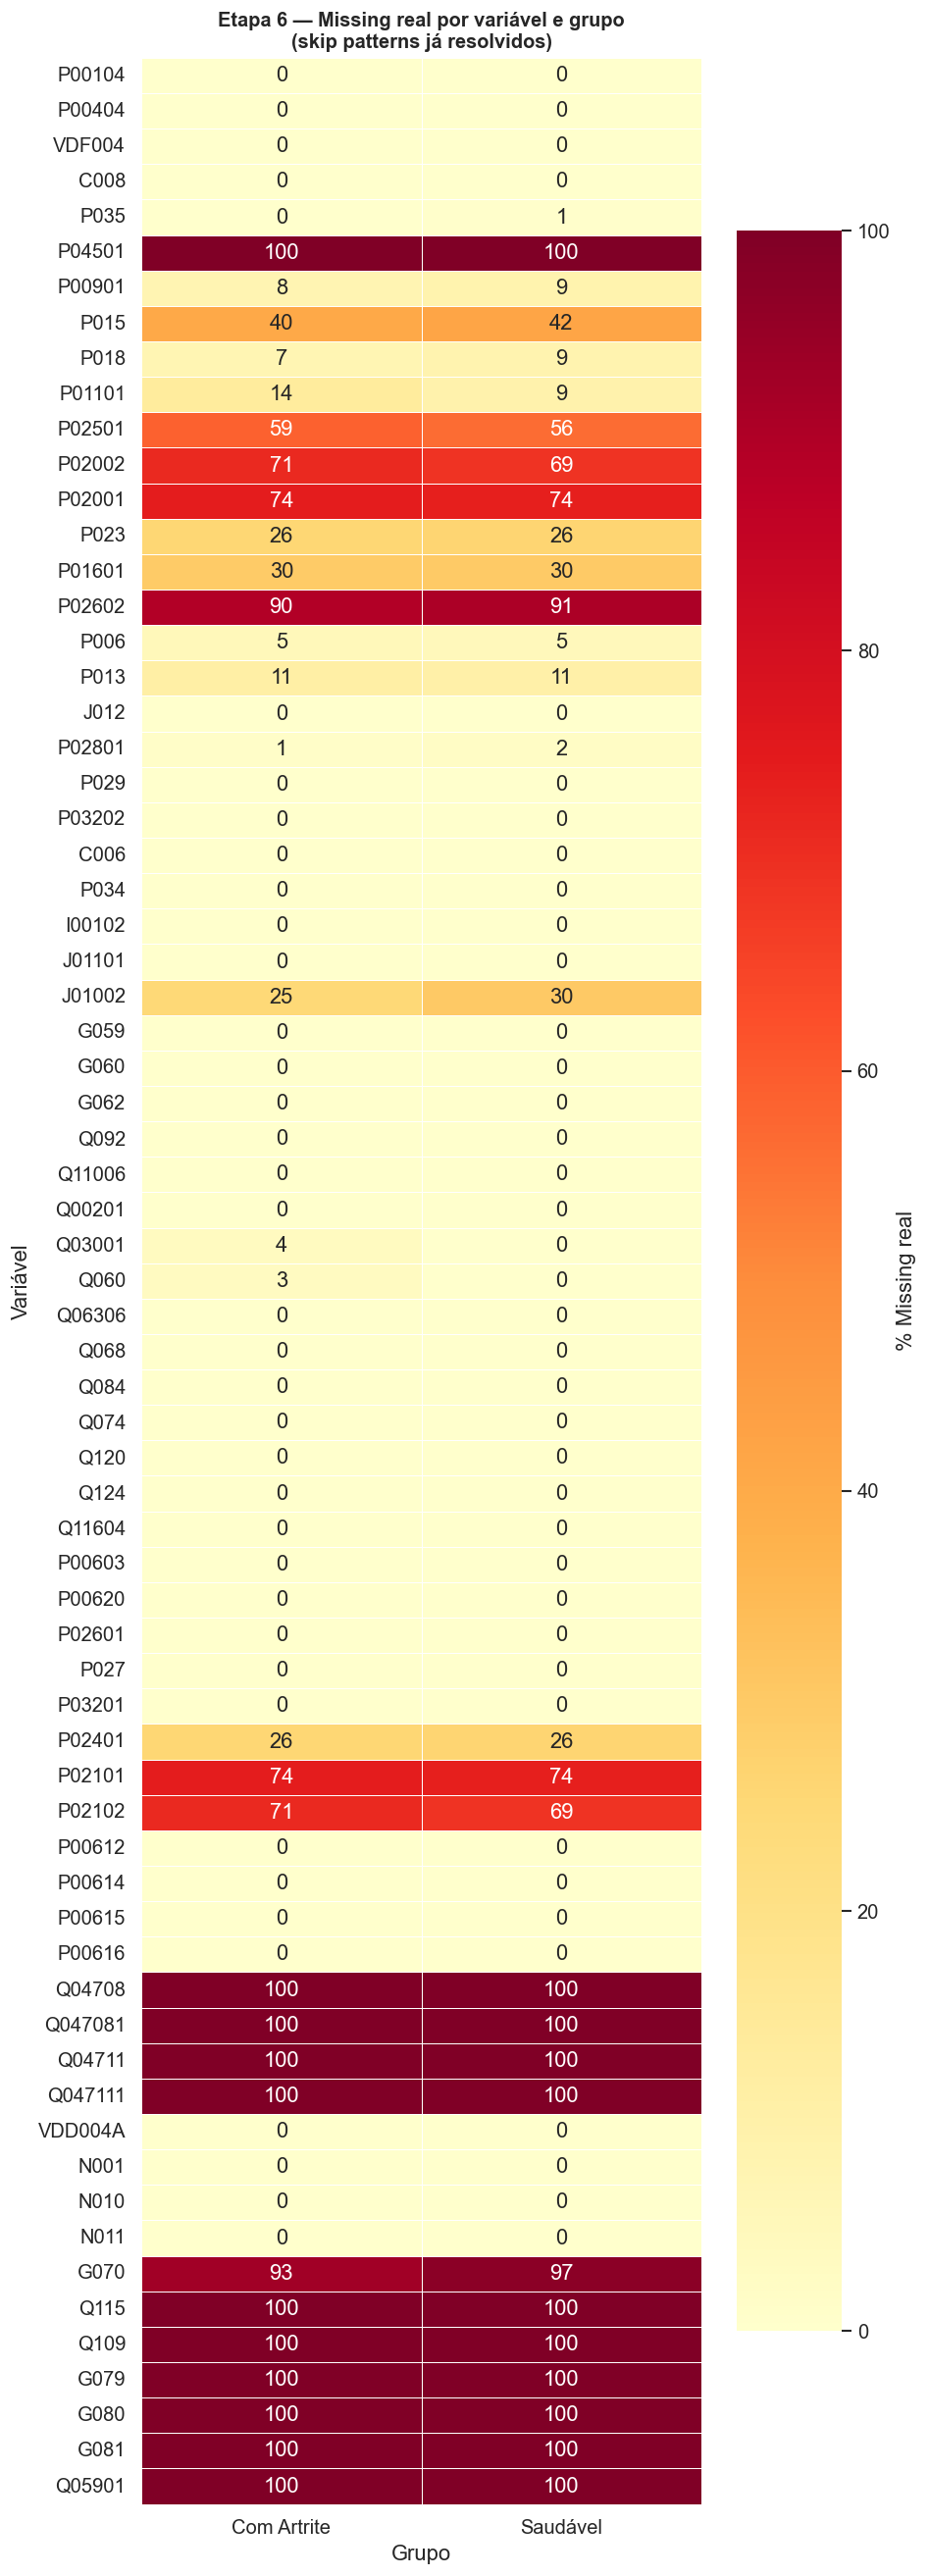

In [6]:
# Colunas que são features (descartando Classe e Q079)
colunas_features = [c for c in df_raw.columns if c not in ['Classe', 'Q079']]

# Calcula % missing de cada feature
taxa_missing = df_raw[colunas_features].isna().mean() * 100  # série %
taxa_missing = taxa_missing.sort_values(ascending=False)     # ordena do maior para menor

# Tabela de auditoria com decisão automática
tab_missing = pd.DataFrame({
    'Variável'  : taxa_missing.index,
    '% Missing' : taxa_missing.values.round(1),
    'n Missing' : df_raw[taxa_missing.index].isna().sum().values,
    'Decisão'   : ['EXCLUIR (>75%)' if p > LIMITE_MISSING * 100 else
                   'IMPUTAR (1–75%)' if p > 0 else
                   'COMPLETA (0%)'
                   for p in taxa_missing.values]
})
print('=' * 70)
print('  AUDITORIA DE MISSING REAL (após skip patterns)')
print('=' * 70)
print(tab_missing.to_string(index=False))
salvar_tab(tab_missing, 'etapa3_auditoria_missing.csv')

# Lista de variáveis a excluir (uso na próxima célula)
vars_excluir = taxa_missing[taxa_missing > LIMITE_MISSING * 100].index.tolist()
print(f'\n  Variáveis a EXCLUIR (>{int(LIMITE_MISSING*100)}% missing real): {vars_excluir}')

# ── Heatmap: % missing por (variável × grupo) ────────────────────────
miss_por_classe = (
    df_raw.groupby('Classe')[colunas_features]
    .apply(lambda g: g.isna().mean() * 100)
    .T  # transpõe: linhas=variáveis, colunas=grupos
)

fig, ax = plt.subplots(figsize=(8, max(8, len(colunas_features) * 0.32)))  # altura proporcional ao nº de vars
sns.heatmap(miss_por_classe, annot=True, fmt='.0f',                        # valores no centro de cada célula
            cmap='YlOrRd', vmin=0, vmax=100,                               # amarelo → vermelho 0–100%
            linewidths=0.4, linecolor='white', ax=ax,
            cbar_kws={'label': '% Missing real'})
ax.set_title('Etapa 6 — Missing real por variável e grupo\n(skip patterns já resolvidos)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Grupo'); ax.set_ylabel('Variável')
plt.tight_layout()
salvar_fig('etapa3_heatmap_missing.png')
plt.show()

### Aplicação do corte

In [7]:
n_vars_antes = df_raw.shape[1] - 2                            # tira Classe e Q079 da contagem
df_step1 = df_raw.drop(columns=vars_excluir, errors='ignore').copy()  # remove as vars com >75% missing

# Atualiza as listas de variáveis tipadas para refletir o que SOBROU
VARS_CONTINUAS_OK = [v for v in VARS_CONTINUAS if v in df_step1.columns]
VARS_DISCRETAS_OK = [v for v in VARS_DISCRETAS  if v in df_step1.columns]
VARS_NOMINAIS_OK  = [v for v in VARS_NOMINAIS   if v in df_step1.columns]
VARS_ORDINAIS_OK  = [v for v in VARS_ORDINAIS   if v in df_step1.columns]
VARS_NUM_OK       = VARS_CONTINUAS_OK + VARS_DISCRETAS_OK     # numéricas que sobreviveram

n_vars_depois = df_step1.shape[1] - 2
print('=' * 70)
print('  RESULTADO DA EXCLUSÃO')
print('=' * 70)
print(f'  Variáveis antes    : {n_vars_antes}')
print(f'  Excluídas (>75%)   : {len(vars_excluir)} → {vars_excluir}')
print(f'  Mantidas           : {n_vars_depois}')
print(f'  Shape após etapa 6 : {df_step1.shape[0]:,} × {df_step1.shape[1]}')

  RESULTADO DA EXCLUSÃO
  Variáveis antes    : 69
  Excluídas (>75%)   : 13 → ['Q05901', 'G079', 'G081', 'G080', 'Q04708', 'P04501', 'Q047081', 'Q04711', 'Q047111', 'Q115', 'Q109', 'G070', 'P02602']
  Mantidas           : 56
  Shape após etapa 6 : 4,826 × 58


## 7 · Remoção de outliers — método IQR × 3,0 por classe

### Como o IQR detecta outliers

Dado um vetor de valores ordenados:

- **Q1** = percentil 25 (primeiro quartil)
- **Q3** = percentil 75 (terceiro quartil)
- **IQR** = Q3 − Q1 (amplitude interquartil)
- **Limites válidos**: `[Q1 − 3·IQR, Q3 + 3·IQR]`

Tudo fora desse intervalo vira **NaN** (e depois será imputado na Etapa 8, ou descartado se a variável fica >75% NaN).

### Por que "por classe"?

Idosos com artrite e idosos saudáveis podem ter **distribuições diferentes** de peso/IMC.
Calcular IQR misturando os dois grupos esconde diferenças clínicas reais e remove
indivíduos legítimos. Calcular por classe respeita a distribuição de cada subgrupo.

### Por que IQR × 3 (e não 1,5)?

`1,5 × IQR` é a regra "boxplot padrão" — agressiva. `3 × IQR` (≈ 3,3 desvios-padrão) só
derruba valores **muito extremos**, o que é apropriado para variáveis de saúde onde
"outlier" geralmente é erro de digitação (200 kg, idade 250), não variação biológica.

In [8]:
df_step2 = df_step1.copy()                          # trabalha em cópia
log_outliers = []                                   # log: 1 linha por variável

for col in VARS_NUM_OK:                             # itera só nas numéricas que sobreviveram
    if col not in df_step2.columns:
        continue
    mask_outlier = pd.Series(False, index=df_step2.index)  # máscara cumulativa: True onde é outlier

    for classe in df_step2['Classe'].unique():      # calcula IQR separadamente para Artrite e Saudável
        idx = df_step2['Classe'] == classe          # linhas dessa classe
        serie = df_step2.loc[idx, col].dropna()     # valores não-nulos
        if len(serie) < 10:                         # poucos dados? não confio no IQR
            continue
        q1, q3 = serie.quantile(0.25), serie.quantile(0.75)  # quartis
        iqr = q3 - q1                                # amplitude interquartil
        if iqr == 0:                                 # variável constante? sem outliers
            continue
        lim_inf = q1 - LIMITE_IQR_MULT * iqr         # limite inferior aceitável
        lim_sup = q3 + LIMITE_IQR_MULT * iqr         # limite superior aceitável
        mask_outlier |= idx & ((df_step2[col] < lim_inf) | (df_step2[col] > lim_sup))  # ou-acumula

    n_out = int(mask_outlier.sum())                  # quantos outliers nesta variável
    if n_out > 0:
        df_step2.loc[mask_outlier, col] = np.nan     # substitui outliers por NaN
        n_validos = int(df_step2[col].notna().sum() + n_out)  # total que era válido antes
        pct_val = 100 * n_out / n_validos if n_validos else 0
        print(f'  {col:12s}: {n_out:4d} outliers → NaN ({pct_val:.2f}% dos válidos)')

    log_outliers.append({
        'Variável': col,
        'n_outliers': n_out,
        '% outliers': round(100*n_out/max(1, int(df_step2[col].notna().sum() + n_out)), 2),
        'Ação': 'Substituído por NaN' if n_out > 0 else 'Sem outliers',
    })

tab_outliers = pd.DataFrame(log_outliers)
salvar_tab(tab_outliers, 'etapa4_log_outliers.csv')
print(f'\n  Total outliers substituídos: {tab_outliers["n_outliers"].sum():,}')

  P00104      :    2 outliers → NaN (0.04% dos válidos)
  C008        :    2 outliers → NaN (0.04% dos válidos)
  P02002      :    7 outliers → NaN (0.47% dos válidos)
  J012        :   24 outliers → NaN (0.50% dos válidos)
  P029        :  285 outliers → NaN (5.91% dos válidos)
  ✅ Tabela → ../data/results/preprocessing/tabelas/etapa4_log_outliers.csv

  Total outliers substituídos: 320


### Visualização antes/depois

Boxplots comparando as variáveis-chave antes e depois da remoção de outliers.
A "caixa" continua igual (Q1–Q3 não muda), o que some são apenas os pontos extremos.

  ✅ Figura → ../data/results/preprocessing/figuras/etapa4_boxplots_outliers.png


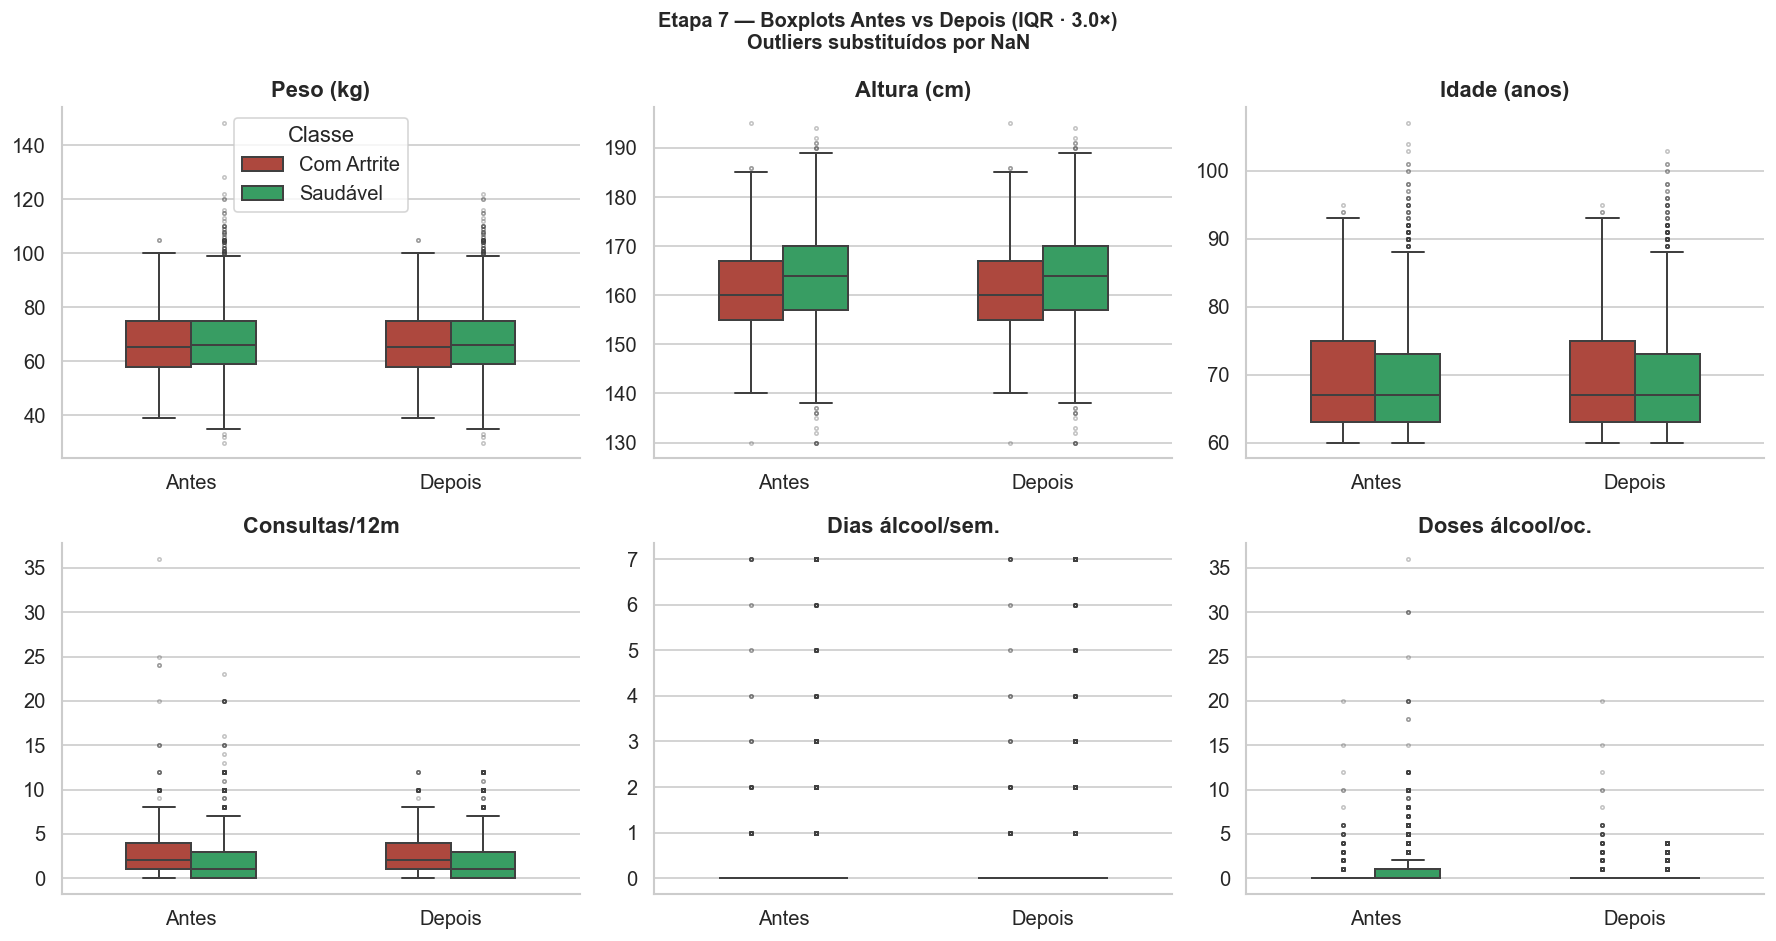

In [9]:
# Variáveis de interesse para visualizar (seleciono as mais sensíveis a outlier)
VARS_VIZ_OUT = [v for v in ['P00104','P00404','C008','J012','P02801','P029']
                if v in df_step1.columns and v in df_step2.columns]
ROTULOS_VIZ = {'P00104':'Peso (kg)','P00404':'Altura (cm)','C008':'Idade (anos)',
               'J012':'Consultas/12m','P02801':'Dias álcool/sem.','P029':'Doses álcool/oc.'}

n_vars = len(VARS_VIZ_OUT)
n_cols = 3                                            # 3 painéis por linha
n_rows = math.ceil(n_vars / n_cols)                   # nº de linhas necessário
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()                                 # achata matriz de eixos em 1D

for i, col in enumerate(VARS_VIZ_OUT):
    ax = axes[i]
    df_a = df_step1[['Classe', col]].copy(); df_a['Etapa'] = 'Antes'
    df_d = df_step2[['Classe', col]].copy(); df_d['Etapa'] = 'Depois'
    df_plot = pd.concat([df_a, df_d], ignore_index=True)
    sns.boxplot(data=df_plot, x='Etapa', y=col, hue='Classe', ax=ax,
                palette={'Com Artrite': COR_ARTRITE, 'Saudável': COR_SAUDAVEL},
                order=['Antes','Depois'], width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(ROTULOS_VIZ.get(col, col), fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    if i > 0: ax.get_legend().remove()                # só a 1ª mantém legenda

# Esconde painéis sobrando (se nº de vars não preenche a grade toda)
if VARS_VIZ_OUT:
    for j in range(len(VARS_VIZ_OUT), len(axes)): axes[j].set_visible(False)

fig.suptitle(f'Etapa 7 — Boxplots Antes vs Depois (IQR · {LIMITE_IQR_MULT}×)\n'
             'Outliers substituídos por NaN', fontsize=12, fontweight='bold')
plt.tight_layout()
salvar_fig('etapa4_boxplots_outliers.png')
plt.show()

## 8 · Imputação de missing real

Depois dos skip patterns (Etapa 5), o missing remanescente é **genuíno**. Preencho com:

- **Numéricas** → **média da própria classe** (preserva diferenças entre Artrite e Saudável)
- **Categóricas** → **moda da própria classe**

### ⚠️ Aviso de data leakage

Imputar com estatísticas da própria classe **usa o target para gerar a feature**. Em
EDA descritiva isso é OK e até desejável (preserva contraste entre grupos). Mas para
**Machine Learning** isso vaza informação do label para X — métricas de CV ficarão
otimistas.

**Mitigação:** no Notebook 04, refazer imputação **dentro de cada fold de CV** usando
só os dados de treino. Aqui só persistimos a versão "descritiva" para o artigo.

### Variáveis com alto missing remanescente

Algumas variáveis (P02001, P029, P03201) podem ter >70% missing real mesmo após
skip patterns — ficaram retidas pois <75%. Recomendar **análise de sensibilidade** no
NB04 (treinar modelo com e sem essas variáveis).

In [10]:
df_step3 = df_step2.copy()        # cópia para imputar
log_imp   = []                     # log: 1 linha por variável

# ── Imputação numérica (média/classe) ────────────────────────────────
for col in VARS_NUM_OK:
    if col not in df_step3.columns: continue
    n_antes = df_step3[col].isna().sum()                          # nº de NaNs antes
    if n_antes == 0:
        log_imp.append({'Variável': col, 'Tipo': 'Numérica',
                        'Método': 'Média/classe', 'n_imputados': 0})
        continue
    for classe in df_step3['Classe'].unique():                    # imputa por classe
        m = df_step3['Classe'] == classe                          # máscara dessa classe
        df_step3.loc[m & df_step3[col].isna(), col] = df_step3.loc[m, col].mean()
    n_imp = int(n_antes - df_step3[col].isna().sum())             # quantos foram preenchidos
    log_imp.append({'Variável': col, 'Tipo': 'Numérica',
                    'Método': 'Média/classe', 'n_imputados': n_imp})
    if n_imp > 0:
        print(f'  NUM {col:12s}: {n_imp:5,} valores imputados (média/classe)')

# ── Imputação qualitativa (moda/classe) ──────────────────────────────
for col in VARS_NOMINAIS_OK + VARS_ORDINAIS_OK:
    if col not in df_step3.columns: continue
    n_antes = df_step3[col].isna().sum()
    if n_antes == 0:
        log_imp.append({'Variável': col, 'Tipo': 'Qualitativa',
                        'Método': 'Moda/classe', 'n_imputados': 0})
        continue
    for classe in df_step3['Classe'].unique():
        m = df_step3['Classe'] == classe
        serie = df_step3.loc[m, col].dropna()
        if len(serie) == 0: continue                              # toda classe NaN? pula
        moda = serie.mode()                                       # pode haver empate
        if len(moda) == 0: continue
        df_step3.loc[m & df_step3[col].isna(), col] = moda.iloc[0]  # primeira moda
    n_imp = int(n_antes - df_step3[col].isna().sum())
    log_imp.append({'Variável': col, 'Tipo': 'Qualitativa',
                    'Método': 'Moda/classe', 'n_imputados': n_imp})
    if n_imp > 0:
        print(f'  CAT {col:12s}: {n_imp:5,} valores imputados (moda/classe)')

tab_imp = pd.DataFrame(log_imp)
salvar_tab(tab_imp, 'etapa5_log_imputacao.csv')
nan_restante = df_step3.drop(columns=['Classe','Q079'], errors='ignore').isna().sum().sum()
print(f'\n  Total imputado : {tab_imp["n_imputados"].sum():,}')
print(f'  NaN residual   : {nan_restante}')
print(f'  Shape          : {df_step3.shape}')

  NUM P00104      :     4 valores imputados (média/classe)
  NUM P00404      :     2 valores imputados (média/classe)
  NUM VDF004      :     1 valores imputados (média/classe)
  NUM C008        :     2 valores imputados (média/classe)
  NUM P035        :    31 valores imputados (média/classe)
  NUM P00901      :   420 valores imputados (média/classe)
  NUM P015        : 2,011 valores imputados (média/classe)
  NUM P018        :   404 valores imputados (média/classe)
  NUM P01101      :   460 valores imputados (média/classe)
  NUM P02501      : 2,733 valores imputados (média/classe)
  NUM P02002      : 3,339 valores imputados (média/classe)
  NUM P02001      : 3,564 valores imputados (média/classe)
  NUM P023        : 1,266 valores imputados (média/classe)
  NUM P01601      : 1,436 valores imputados (média/classe)
  NUM P006        :   234 valores imputados (média/classe)
  NUM P013        :   510 valores imputados (média/classe)
  NUM J012        :    24 valores imputados (média/class

## 9 · Fusão de atributos (feature engineering)

Combina variáveis brutas em **features compostas** mais informativas para o ML:

| Feature | Fórmula | Hipótese |
|---------|---------|----------|
| **IMC** | Peso / Altura² | Obesidade ↑ inflamação ↑ artrite |
| **Escore_Inflamatorio** | Σ(carne vermelha, doces, refrigerante, suco artificial) | Alimentos pró-inflamatórios → ↑ risco |
| **Escore_Saudavel** | Σ(frutas, verduras, peixe, leite, suco natural) | Alimentos protetores → ↓ risco |
| **Razao_Inf_Saud** | Inflamatório / (Saudável + 1) | Quanto maior, pior o padrão alimentar |

O `+1` no denominador da razão evita divisão por zero quando o escore saudável é 0.

In [11]:
df_step4 = df_step3.copy()                       # cópia para criar features

# ── IMC ──────────────────────────────────────────────────────────────
if 'P00104' in df_step4.columns and 'P00404' in df_step4.columns:
    peso   = pd.to_numeric(df_step4['P00104'], errors='coerce')        # kg
    altura = pd.to_numeric(df_step4['P00404'], errors='coerce') / 100  # cm → m
    df_step4['IMC'] = peso / (altura ** 2)                              # kg/m²
    # Filtro de sanidade: IMC fora de [10, 70] é erro de medição
    df_step4.loc[(df_step4['IMC'] < 10) | (df_step4['IMC'] > 70), 'IMC'] = np.nan
    print(f'  ✅ IMC | média={df_step4["IMC"].mean():.1f} | NaN={df_step4["IMC"].isna().sum()}')

# ── Escore Inflamatório (soma de hábitos pró-inflamatórios) ──────────
vars_infla = [v for v in ['P01101','P02501','P02002','P02001'] if v in df_step4.columns]
if vars_infla:
    df_step4['Escore_Inflamatorio'] = df_step4[vars_infla].sum(axis=1, min_count=1)  # ignora linhas all-NaN
    print(f'  ✅ Escore_Inflamatorio | componentes={vars_infla} | média={df_step4["Escore_Inflamatorio"].mean():.1f}')

# ── Escore Saudável (soma de hábitos protetores) ─────────────────────
vars_saud = [v for v in ['P018','P00901','P015','P023','P01601'] if v in df_step4.columns]
if vars_saud:
    df_step4['Escore_Saudavel'] = df_step4[vars_saud].sum(axis=1, min_count=1)
    print(f'  ✅ Escore_Saudavel | componentes={vars_saud} | média={df_step4["Escore_Saudavel"].mean():.1f}')

# ── Razão Inf/Saud (índice composto) ─────────────────────────────────
if 'Escore_Inflamatorio' in df_step4.columns and 'Escore_Saudavel' in df_step4.columns:
    df_step4['Razao_Inf_Saud'] = df_step4['Escore_Inflamatorio'] / (df_step4['Escore_Saudavel'] + 1)
    print(f'  ✅ Razao_Inf_Saud | média={df_step4["Razao_Inf_Saud"].mean():.2f}')
    print(f'     💡 Considerar log(Razao_Inf_Saud) no NB04 para reduzir assimetria.')

# Imputa NaN das features de engenharia (IMC/escores) pela mediana da classe,
# evitando que valores invalidos (ex.: IMC fora de [10,70]) virem 0 no fillna final (Etapa 12).
for _feat in ['IMC','Escore_Inflamatorio','Escore_Saudavel','Razao_Inf_Saud']:
    if _feat in df_step4.columns and df_step4[_feat].isna().any():
        for _cl in df_step4['Classe'].unique():
            _m = df_step4['Classe'] == _cl
            df_step4.loc[_m & df_step4[_feat].isna(), _feat] = df_step4.loc[_m, _feat].median()
        print(f'  [fix] {_feat}: NaN imputados pela mediana da classe (residuo={int(df_step4[_feat].isna().sum())})')

print(f'\n  Dataset após etapa 9: {df_step4.shape[0]:,} × {df_step4.shape[1]}')

  ✅ IMC | média=25.3 | NaN=0
  ✅ Escore_Inflamatorio | componentes=['P01101', 'P02501', 'P02002', 'P02001'] | média=12.5
  ✅ Escore_Saudavel | componentes=['P018', 'P00901', 'P015', 'P023', 'P01601'] | média=21.3
  ✅ Razao_Inf_Saud | média=0.59
     💡 Considerar log(Razao_Inf_Saud) no NB04 para reduzir assimetria.

  Dataset após etapa 9: 4,826 × 62


## 10 · Categorização ordinal — **migrada para o NB04**

> **Opção A (fonte única de discretização).** A binagem das variáveis contínuas (IMC, faixa etária, atividade física, escores) foi **centralizada no Notebook 04 — Discretização**. Aqui o NB03 entrega as contínuas ainda **numéricas**; o NB04 aplica os cortes por domínio (OMS, Guia de Atividade Física BR…) com rastreabilidade e fonte de cada corte. Isso evita discretizar em dois lugares — mesmo princípio que levou a isolar o tratamento de outliers.

In [12]:
df_step5 = df_step4.copy()   # passthrough — discretização migrada para o NB04 (Opção A)

# A categorização ordinal das variáveis CONTÍNUAS (IMC, idade, atividade física, escores)
# foi centralizada no Notebook 04 (Discretização), para manter UMA única fonte da verdade
# e justificar cada corte por domínio. Neste notebook as contínuas seguem NUMÉRICAS.
# (O encoding de nominais/ordinais permanece na Etapa 11.)
novas_cat = []   # nenhuma feature _cat criada aqui — mantido p/ compat. do relatório/sumário

print('  ℹ️  Discretização migrada para o NB04 — contínuas mantidas numéricas.')
print(f'  Dataset após etapa 9 (sem categorização): {df_step5.shape[0]:,} × {df_step5.shape[1]}')

  ℹ️  Discretização migrada para o NB04 — contínuas mantidas numéricas.
  Dataset após etapa 9 (sem categorização): 4,826 × 62


## 11 · Encoding para o modelo de ML

Modelos de scikit-learn **não aceitam string como input** — só números. Há duas técnicas:

### Label Encoding (ordinais)

Mantém a ordem natural: `1=Muito boa < 2=Boa < 3=Regular < 4=Ruim < 5=Muito ruim`.
Para o sklearn, preciso normalizar para começar em 0 → subtraio o mínimo.

### One-Hot Encoding (nominais)

Cria uma coluna binária por categoria. Ex.: `Sexo` vira `Sexo_Feminino` (1 ou 0).
Uso `drop_first=True` para evitar a "dummy variable trap" em modelos lineares.
Uso `dtype=int` para garantir colunas numéricas (não bool).

**Q092 (depressão)** é removida explicitamente:  na amostra "artrite pura" (que exclui
comorbidades mentais), Q092 é constante em 'Não'. Variável constante é inútil como preditor.

In [13]:
df_step6 = df_step5.copy()

# ── Label Encoding (variáveis ordinais) ──────────────────────────────
cols_label = [c for c in VARS_ORDINAIS_OK if c in df_step6.columns]
print('  Label Encoding (ordinais):')
if cols_label:
    for col in cols_label:
        col_num = pd.to_numeric(df_step6[col], errors='coerce')   # garante numérico
        col_min = col_num.min()                                    # mínimo observado
        if col_min > 0:
            df_step6[col] = (col_num - col_min).astype(float)     # reescala para começar em 0
            print(f'    {col}: mín={col_min:.0f} → ajustado para 0')
        else:
            df_step6[col] = col_num                                # já começa em 0 ou negativo
            print(f'    {col}: já começa em 0')
else:
    print('    Nenhuma ordinal mantida (todas excluídas na Etapa 6).')

# ── One-Hot Encoding (variáveis nominais, exceto Q092) ───────────────
cols_ohe = [c for c in VARS_NOMINAIS_OK if c in df_step6.columns and c != 'Q092']
print(f'\n  OHE ({len(cols_ohe)} variáveis nominais):')

if cols_ohe:
    dummies = pd.get_dummies(
        df_step6[cols_ohe],
        prefix=cols_ohe,
        drop_first=True,       # evita dummy trap em modelos lineares
        dummy_na=False,        # ignora NaN (não deveria haver após imputação)
        dtype=int              # garante int (não bool)
    )
    df_step6.drop(columns=cols_ohe, inplace=True)            # remove originais
    df_step6 = pd.concat([df_step6, dummies], axis=1)         # concatena as dummies
    print(f'    {len(dummies.columns)} colunas binárias criadas.')

    # Diagnóstico: variáveis que não geraram colunas (constantes na amostra)
    vars_nao_geradas = [c for c in cols_ohe
                        if not any(col.startswith(c) for col in df_step6.columns)]
    if vars_nao_geradas:
        print(f'\n  ⚠️  OHE não gerou colunas para: {vars_nao_geradas}')
        print(f'     Causa: constantes nesta amostra (declarar como limitação).')

# ── Remove Q092 explicitamente (constante na amostra artrite pura) ───
if 'Q092' in df_step6.columns:
    df_step6.drop(columns=['Q092'], inplace=True)
    print('\n  ✅ Q092 removida do DataFrame (constante na amostra).')

print(f'\n  Dataset após etapa 11: {df_step6.shape[0]:,} × {df_step6.shape[1]}')

  Label Encoding (ordinais):
    VDD004A: mín=1 → ajustado para 0
    N001: mín=1 → ajustado para 0
    N010: mín=1 → ajustado para 0
    N011: mín=1 → ajustado para 0

  OHE (31 variáveis nominais):


    41 colunas binárias criadas.

  ⚠️  OHE não gerou colunas para: ['Q11006', 'Q00201', 'Q03001', 'Q060', 'Q06306', 'Q068', 'Q074', 'Q120', 'Q124', 'Q11604']
     Causa: constantes nesta amostra (declarar como limitação).

  ✅ Q092 removida do DataFrame (constante na amostra).

  Dataset após etapa 11: 4,826 × 71


## 12 · Construção do dataset final (X, y)

Monta as duas estruturas que o sklearn espera:

- **`X`** — matriz de features (N × P, numérica)
- **`y`** — vetor do target (N, binário 0/1)

`Label = 1` se Classe == 'Com Artrite', `0` caso contrário.

### Sanidade

- Confirma que X é 100% numérico (sem categorias residuais)
- Conta NaNs residuais (não deveria haver após Etapa 8)
- Reporta razão de desbalanceamento — se >1,5:1, marca para **RUS** no NB04

In [14]:
df_final = df_step6.copy()
df_final['Label'] = (df_final['Classe'] == 'Com Artrite').astype(int)    # cria target binário

X = df_final.drop(columns=['Classe', 'Q079', 'Label'], errors='ignore')  # features
y = df_final['Label']                                                     # target

# ── Verifica se X é 100% numérico ────────────────────────────────────
cols_nao_num = X.select_dtypes(exclude=['number']).columns.tolist()
if cols_nao_num:
    print(f'  ⚠️  Colunas não-numéricas: {cols_nao_num}')
    for col in cols_nao_num:
        codes = pd.Categorical(X[col]).codes                              # converte para int codes
        X[col] = np.where(codes == -1, 0, codes).astype(int)              # -1 (NaN) vira 0
else:
    print('  ✅ X 100% numérico.')

# ── NaN residual (não deveria existir após imputação) ────────────────
nan_restante = X.isna().sum().sum()
if nan_restante > 0:
    print(f'  ⚠️  {nan_restante} NaN residuais → fill=0.')
    X.fillna(0, inplace=True)
else:
    print('  ✅ Nenhum NaN residual.')

# ── Diagnóstico de balanceamento ─────────────────────────────────────
contagem_label = y.value_counts().to_dict()
razao = max(contagem_label.values()) / min(contagem_label.values())
print(f'\n  Distribuição do alvo:')
print(f'    Saudável (0)   : {contagem_label.get(0,0):,}')
print(f'    Com Artrite (1): {contagem_label.get(1,0):,}')
print(f'    Razão          : {razao:.2f}:1')
if razao > 1.5:
    print(f'    ⚠️  Desbalanceamento severo → aplicar RUS no NB04.')
print(f'\n  Shape final: X={X.shape}, y={y.shape}')

  ✅ X 100% numérico.
  ✅ Nenhum NaN residual.

  Distribuição do alvo:
    Saudável (0)   : 4,332
    Com Artrite (1): 494
    Razão          : 8.77:1
    ⚠️  Desbalanceamento severo → aplicar RUS no NB04.

  Shape final: X=(4826, 69), y=(4826,)


### Diagnóstico visual do dataset final

  ✅ Figura → ../data/results/preprocessing/figuras/etapa9_diagnostico_dataset_final.png


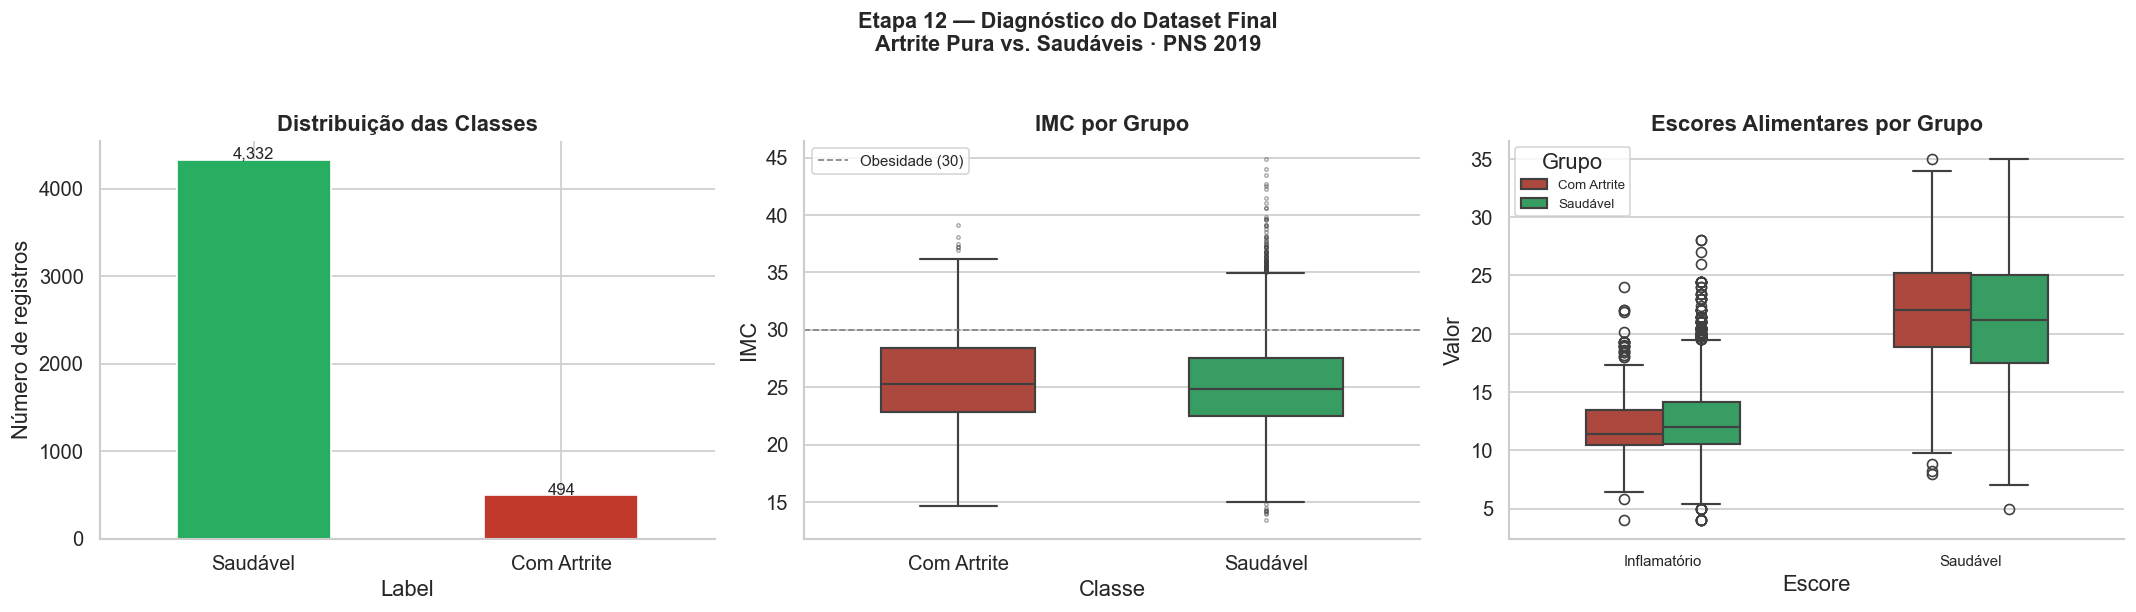

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Painel 1: distribuição das classes ───────────────────────────────
contagem = y.value_counts().rename(index={0: 'Saudável', 1: 'Com Artrite'})
contagem.plot(kind='bar', ax=axes[0],
              color=[COR_SAUDAVEL, COR_ARTRITE],
              edgecolor='white', rot=0)
axes[0].set_title('Distribuição das Classes', fontweight='bold')
axes[0].set_ylabel('Número de registros')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontsize=10)

# ── Painel 2: IMC por grupo ──────────────────────────────────────────
if 'IMC' in df_final.columns:
    sns.boxplot(data=df_final, x='Classe', y='IMC', ax=axes[1],
                palette={'Com Artrite': COR_ARTRITE, 'Saudável': COR_SAUDAVEL},
                order=['Com Artrite', 'Saudável'], width=0.5, linewidth=1.3,
                flierprops=dict(marker='o', markersize=2, alpha=0.4))
    axes[1].set_title('IMC por Grupo', fontweight='bold')
    axes[1].axhline(30, color='gray', linestyle='--', linewidth=1, label='Obesidade (30)')
    axes[1].legend(fontsize=9)

# ── Painel 3: escores alimentares ────────────────────────────────────
if 'Escore_Inflamatorio' in df_final.columns and 'Escore_Saudavel' in df_final.columns:
    df_esc = pd.melt(df_final[['Classe', 'Escore_Inflamatorio', 'Escore_Saudavel']],
                     id_vars='Classe', var_name='Escore', value_name='Valor')
    sns.boxplot(data=df_esc, x='Escore', y='Valor', hue='Classe', ax=axes[2],
                palette={'Com Artrite': COR_ARTRITE, 'Saudável': COR_SAUDAVEL},
                width=0.5, linewidth=1.3)
    axes[2].set_title('Escores Alimentares por Grupo', fontweight='bold')
    axes[2].set_xticklabels(['Inflamatório', 'Saudável'], fontsize=9)
    axes[2].legend(title='Grupo', fontsize=8)

fig.suptitle('Etapa 12 — Diagnóstico do Dataset Final\nArtrite Pura vs. Saudáveis · PNS 2019',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
salvar_fig('etapa9_diagnostico_dataset_final.png')
plt.show()

## 13 · Exportação e rastreabilidade

Grava dois artefatos:

1. **`dataset_preprocessado.csv`** — entrada do Notebook 04 (ML)
2. **`relatorio_preprocessamento.json`** — registra cada decisão metodológica:
   - Hiperparâmetros usados
   - Variáveis excluídas e por quê
   - Outliers substituídos
   - Imputações realizadas
   - Features criadas
   - Encoding aplicado

Esse JSON é **insumo direto para a seção Métodos do artigo** — copia os números literalmente.

In [16]:
# ── Exporta o dataset final ──────────────────────────────────────────
df_export = X.copy()
df_export['Label'] = y.values
caminho_dataset = DIR_RESULTADOS + 'dataset_preprocessado.csv'
df_export.to_csv(caminho_dataset, index=False, encoding='utf-8-sig')
print(f'  ✅ Dataset → {caminho_dataset}  ({df_export.shape[0]:,} × {df_export.shape[1]})')

# ── Monta o relatório de rastreabilidade ─────────────────────────────
relatorio = {
    'projeto'    : 'Artrite e Reumatismo em Idosos Brasileiros — PNS 2019',
    'pesquisador': 'Pedro Dias Soares',
    'orientador' : 'Prof. Dr. Luis Enrique Zárate — PUC Minas',
    'notebook'   : '03_preprocessamento',
    'versao'     : 'v3 — skip patterns resolvidos',
    'parametros' : {
        'LIMITE_MISSING_pct'  : LIMITE_MISSING * 100,
        'LIMITE_IQR_MULT'     : LIMITE_IQR_MULT,
        'RANDOM_STATE'        : RANDOM_STATE,
        'metodo_imputacao_num': 'Média por classe (missing real)',
        'metodo_imputacao_cat': 'Moda por classe (missing real)',
    },
    'rastreabilidade': {
        'etapa_1_carga': {
            'registros_brutos'    : int(sum(r['n_bruto'] for r in log_carga)),
            'registros_validos'   : int(df_raw.shape[0]),
            'variaveis_carregadas': int(df_raw.shape[1]),
        },
        'etapa_2_5_skip_patterns': {
            'total_preenchidos': int(tab_skip['n_preenchidos'].sum()),
            'detalhes'         : tab_skip.to_dict('records'),
        },
        'etapa_3_missing': {
            'vars_excluidas_>75pct': vars_excluir,
            'n_excluidas'          : len(vars_excluir),
        },
        'etapa_4_outliers': {
            'total_outliers_substituidos': int(tab_outliers['n_outliers'].sum()),
            'parametro_usado'            : f'{LIMITE_IQR_MULT}xIQR por classe',
            'detalhes': tab_outliers[tab_outliers['n_outliers'] > 0][
                ['Variável','n_outliers','% outliers']
            ].to_dict('records'),
        },
        'etapa_5_imputacao': {
            'total_imputados'  : int(tab_imp['n_imputados'].sum()),
            'nan_residual_em_X': int(nan_restante),
            'detalhes': tab_imp[tab_imp['n_imputados'] > 0][
                ['Variável','Tipo','Método','n_imputados']
            ].to_dict('records'),
        },
        'etapa_6_fusao': {
            'features_criadas' : ['IMC','Escore_Inflamatorio','Escore_Saudavel','Razao_Inf_Saud'],
            'formula_imc'      : 'Peso(kg) / (Altura(m))²',
            'componentes_infla': vars_infla,
            'componentes_saud' : vars_saud,
        },
        'etapa_7_categorizacao': {
            'features_cat_criadas': novas_cat,
            'limitacao'           : 'Renda_cat/Saude_cat não criadas se VDF004/N001=100% missing',
        },
        'etapa_8_encoding': {
            'label_encoding': cols_label,
            'ohe_encoding'  : cols_ohe,
            'excluidas_ohe' : ['Q092 (constante na amostra artrite pura)'],
            'removidas_df'  : ['Q092'],
        },
        'etapa_9_dataset_final': {
            'n_registros'           : int(X.shape[0]),
            'n_features'            : int(X.shape[1]),
            'distribuicao_label'    : {str(k): int(v) for k, v in y.value_counts().items()},
            'razao_desbalanceamento': round(razao, 2),
            'arquivo'               : caminho_dataset,
        },
    },
}

caminho_relatorio = DIR_RESULTADOS + 'relatorio_preprocessamento.json'
with open(caminho_relatorio, 'w', encoding='utf-8') as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)
print(f'  ✅ Relatório → {caminho_relatorio}')

  ✅ Dataset → ../data/results/preprocessing/dataset_preprocessado.csv  (4,826 × 70)
  ✅ Relatório → ../data/results/preprocessing/relatorio_preprocessamento.json


## ✅ Sumário Final

Imprime um resumo executivo de todas as etapas — útil para conferir num relance que
o pipeline rodou como esperado e copiar números para o artigo.

In [17]:
print('=' * 80)
print('  ✅  NOTEBOOK 03 — PRÉ-PROCESSAMENTO CONCLUÍDO')
print('=' * 80)

print('\n  RESUMO DAS ETAPAS:')
print(f'  [1]  Carregamento        : {df_raw.shape[0]:,} registros × {df_raw.shape[1]} colunas')
print(f'  [5]  Skip Patterns       : {tab_skip["n_preenchidos"].sum():,} NaNs estruturais preenchidos')
for _, row in tab_skip.iterrows():
    print(f'       {row["Variável"]:8s}: {row["n_preenchidos"]:5,} ({row["Condição"][:45]})')
print(f'  [6]  Auditoria missing   : {len(vars_excluir)} variáveis excluídas (>{int(LIMITE_MISSING*100)}%)')
print(f'  [7]  Outliers            : {int(tab_outliers["n_outliers"].sum()):,} → NaN ({LIMITE_IQR_MULT}×IQR/classe)')
print(f'  [8]  Imputação           : {int(tab_imp["n_imputados"].sum()):,} valores imputados')
print(f'  [9]  Fusão               : IMC, Escore_Infla, Escore_Saud, Razao')
print(f'  [10] Categorização       : migrada para o NB04 (contínuas numéricas)')
print(f'  [11] Encoding            : Label Enc. + OHE (drop_first=True, dtype=int)')
print(f'  [12] Dataset final       : {X.shape[0]:,} × {X.shape[1]} features + Label')

print('\n  DISTRIBUIÇÃO DO ALVO:')
for label, nome in [(0, 'Saudável (0)'), (1, 'Com Artrite (1)')]:
    n   = int((y == label).sum())
    pct = 100 * n / len(y)
    print(f'    {nome:18s}: {n:,} ({pct:.1f}%)')

print('\n  IMPACTO DOS SKIP PATTERNS (comparação metodológica):')
print('  Variável  | Antes (com NaN estrut.)  | Depois (valores corretos)')
print('  --------- | ------------------------ | -------------------------')
print('  J012      | NaN imputado pela média  | 0 para quem não consultou no ano')
print('  P035      | NaN imputado pela média  | 0 para quem não praticou exercício')
print('  P02801    | NaN imputado pela média  | 0 para quem nunca/raramente bebe')
print('  P029      | NaN imputado pela média  | 0 para quem nunca bebe')
print('  P03201    | NaN imputado pela moda   | "Não" para quem nunca bebe')

print('\n' + '=' * 80)
print('  Próximo → Notebook 04: RUS + Algoritmos ML')
print('  Análise de sensibilidade recomendada: treinar com/sem P035, P02001, P029')
print('=' * 80)

  ✅  NOTEBOOK 03 — PRÉ-PROCESSAMENTO CONCLUÍDO

  RESUMO DAS ETAPAS:
  [1]  Carregamento        : 4,826 registros × 71 colunas
  [5]  Skip Patterns       : 29,274 NaNs estruturais preenchidos
       P035    : 3,444 (P034=2 (Não pratica))
       P02801  : 3,863 (P027∈{1,2} (não bebe sem.))
       P029    : 3,419 (P027=1 (nunca bebe))
       P03201  : 3,419 (P027=1 (nunca bebe))
       J012    : 1,344 (J01101≠1 (não consultou))
       G060    : 4,676 (G059=2 (não usa aparelho))
       G062    : 4,676 (G059=2 (não usa aparelho))
       P03202  : 4,433 (P03201≠1 (não fez binge))
  [6]  Auditoria missing   : 13 variáveis excluídas (>75%)
  [7]  Outliers            : 320 → NaN (3.0×IQR/classe)
  [8]  Imputação           : 26,443 valores imputados
  [9]  Fusão               : IMC, Escore_Infla, Escore_Saud, Razao
  [10] Categorização       : migrada para o NB04 (contínuas numéricas)
  [11] Encoding            : Label Enc. + OHE (drop_first=True, dtype=int)
  [12] Dataset final       : 4,826 ×